In [2]:
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline

Dataset found: 10u, 10v, 2d, 2t, tp, cp — 17,544 hourly steps (2024-01-01 → 2025-12-31), 109 × 321 grid at 0.25°, lat 24–51 N, lon −140 to −60.

Two caveats: the header scan runs on every open (cache with ds.to_netcdf() or Zarr if you reopen often), and tp/cp are accumulations in metres, so multiply by 1000 for mm/h.

In [3]:
grib_file_path = "/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/ERA5/ERA5_2024_2025_select_vars.grib"

ds = xr.open_dataset(grib_file_path, engine="xrgrib")
wind_ds = ds[["10u", "10v"]]          # not "10m_u_component_of_wind"
wind_ds

<xarray.Dataset> Size: 5GB
Dimensions:    (time: 17544, latitude: 109, longitude: 321)
Coordinates:
  * time       (time) datetime64[ns] 140kB 2024-01-01 ... 2025-12-31T23:00:00
  * latitude   (latitude) float64 872B 51.0 50.75 50.5 50.25 ... 24.5 24.25 24.0
  * longitude  (longitude) float64 3kB -140.0 -139.8 -139.5 ... -60.25 -60.0
Data variables:
    10u        (time, latitude, longitude) float32 2GB ...
    10v        (time, latitude, longitude) float32 2GB ...

In [4]:
ds


<xarray.Dataset> Size: 15GB
Dimensions:    (time: 17544, latitude: 109, longitude: 321)
Coordinates:
  * time       (time) datetime64[ns] 140kB 2024-01-01 ... 2025-12-31T23:00:00
  * latitude   (latitude) float64 872B 51.0 50.75 50.5 50.25 ... 24.5 24.25 24.0
  * longitude  (longitude) float64 3kB -140.0 -139.8 -139.5 ... -60.25 -60.0
Data variables:
    10u        (time, latitude, longitude) float32 2GB ...
    10v        (time, latitude, longitude) float32 2GB ...
    2d         (time, latitude, longitude) float32 2GB ...
    2t         (time, latitude, longitude) float32 2GB ...
    tp         (time, latitude, longitude) float32 2GB ...
    cp         (time, latitude, longitude) float32 2GB ...

In [8]:
precip_ds = ds[['tp']]
precip_ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 17544, latitude: 109, longitude: 321)
Coordinates:
  * time       (time) datetime64[ns] 140kB 2024-01-01 ... 2025-12-31T23:00:00
  * latitude   (latitude) float64 872B 51.0 50.75 50.5 50.25 ... 24.5 24.25 24.0
  * longitude  (longitude) float64 3kB -140.0 -139.8 -139.5 ... -60.25 -60.0
Data variables:
    tp         (time, latitude, longitude) float32 2GB ...

In [13]:
precip_ds.sel(time=slice("2024-02-01", "2024-02-05"))

<xarray.Dataset> Size: 17MB
Dimensions:    (time: 120, latitude: 109, longitude: 321)
Coordinates:
  * time       (time) datetime64[ns] 960B 2024-02-01 ... 2024-02-05T23:00:00
  * latitude   (latitude) float64 872B 51.0 50.75 50.5 50.25 ... 24.5 24.25 24.0
  * longitude  (longitude) float64 3kB -140.0 -139.8 -139.5 ... -60.25 -60.0
Data variables:
    tp         (time, latitude, longitude) float32 17MB ...

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

var_to_plot = 'tp'

# 1. Setup the figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Load and clip the county boundary file
counties_path = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/location_data/counties.geojson"
gdf_counties = gpd.read_file(counties_path)
gdf_counties = gdf_counties.cx[-125:-65, 25:50]

# 3. Filter your ERA5 dataset down to just one single day
single_day_ds = precip_ds.sel(time=slice("2024-02-01", "2024-02-05"))
time_steps = single_day_ds.time.values

# Calculate fixed min/max wind limits across the whole day for stable colors
vmin = float(single_day_ds[var_to_plot].min())
vmax = float(single_day_ds[var_to_plot].max())

# --- FIX: Create a permanent, standalone colorbar outside the loop ---
# We use a dummy plot image to build the colorbar structure without cluttering the screen
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.03)
cbar.set_label(var_to_plot)

# 4. Define the base layout template
def init():
    ax.set_xlim(-125, -65)
    ax.set_ylim(25, 50)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

# 5. Define the update function called for every hour frame
def update(frame_idx):
    ax.clear()
    init()
    
    # Extract the current hourly data array slice
    current_raster = single_day_ds[var_to_plot].isel(time=frame_idx)
    
    # Plot wind raster - removed cbar_kwargs to fix the ValueError
    current_raster.plot(
        cmap=plt.cm.coolwarm, 
        vmin=vmin,
        vmax=vmax,
        ax=ax,
        add_colorbar=False 
    )
    
    # Overlay the county line network
    gdf_counties.boundary.plot(ax=ax, color="black", linewidth=0.4, alpha=0.7)
    
    # Update title timestamp
    timestamp_str = str(time_steps[frame_idx])[:16]
    ax.set_title(f"ERA5 - {var_to_plot} | {timestamp_str}", fontsize=14, pad=10)

# 6. Build the animation sequence
anim = FuncAnimation(
    fig, 
    update, 
    init_func=init, 
    frames=len(time_steps), 
    interval=200, 
    blit=False     
)

# 7. Render and play inline within the Notebook cell
plt.close() 
HTML(anim.to_jshtml())


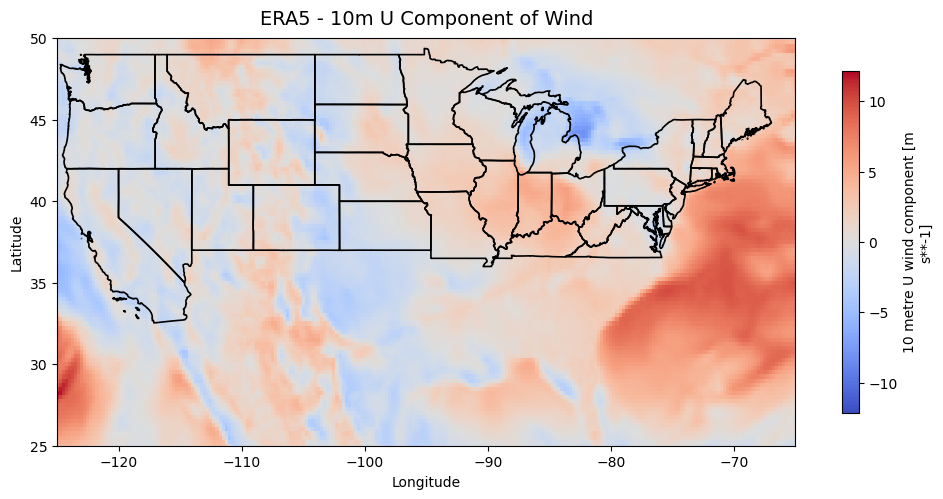

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Initialize the figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Plot the raster data array FIRST (so boundaries sit on top)
# (Assumes 'wind_ds' is already opened using xarray)
wind_ds['10u'][0].plot(
    cmap=plt.cm.coolwarm, 
    cbar_kwargs={"shrink": 0.6}, 
    ax=ax
)

# 3. Load and overlay your spatial boundary array on top
file_path = "/Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/data/selected_states_May2024_event.geojson"
gdf_aoi = gpd.read_file(file_path)
gdf_aoi.boundary.plot(ax=ax, color="black", linewidth=1.2)

# 4. Set map decorations and spatial limits
plt.title("ERA5 - 10m U Component of Wind", fontsize=14, pad=10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Set extent for Continental US
ax.set_xlim(-125, -65)
ax.set_ylim(25, 50)

# 5. Render the final composite layout
plt.tight_layout()
plt.show()
